In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import(
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import joblib

In [2]:
df=pd.read_csv("archive (2)/engine_data.csv")
print("Dataset shape:",df.shape)
df.head()

Dataset shape: (19535, 7)


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
0,700,2.493592,11.790927,3.178981,84.144163,81.632187,1
1,876,2.941606,16.193866,2.464504,77.640934,82.445724,0
2,520,2.961746,6.553147,1.064347,77.752266,79.645777,1
3,473,3.707835,19.510172,3.727455,74.129907,71.774629,1
4,619,5.672919,15.738871,2.052251,78.396989,87.000225,0


In [3]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Columns:
['Engine rpm', 'Lub oil pressure', 'Fuel pressure', 'Coolant pressure', 'lub oil temp', 'Coolant temp', 'Engine Condition']

Data types:
Engine rpm            int64
Lub oil pressure    float64
Fuel pressure       float64
Coolant pressure    float64
lub oil temp        float64
Coolant temp        float64
Engine Condition      int64
dtype: object

Missing values:
Engine rpm          0
Lub oil pressure    0
Fuel pressure       0
Coolant pressure    0
lub oil temp        0
Coolant temp        0
Engine Condition    0
dtype: int64

Duplicate rows:
0


In [4]:
print(df["Engine Condition"].value_counts())

print("\nPercentage:")
print(df["Engine Condition"].value_counts(normalize=True)*100)

Engine Condition
1    12317
0     7218
Name: count, dtype: int64

Percentage:
Engine Condition
1    63.050934
0    36.949066
Name: proportion, dtype: float64


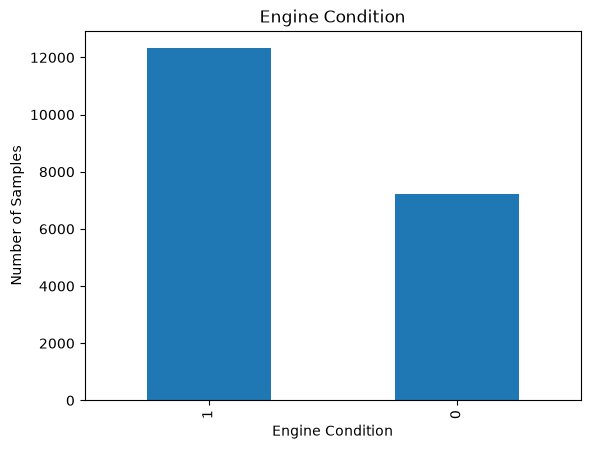

In [5]:
df["Engine Condition"].value_counts().plot(kind="bar")
plt.title("Engine Condition")
plt.xlabel("Engine Condition")
plt.ylabel("Number of Samples")
plt.show()

In [6]:
for column in df.columns:
    print(repr(column))

'Engine rpm'
'Lub oil pressure'
'Fuel pressure'
'Coolant pressure'
'lub oil temp'
'Coolant temp'
'Engine Condition'


In [7]:
print(df["Engine Condition"].unique())
print (df["Engine Condition"].value_counts())

[1 0]
Engine Condition
1    12317
0     7218
Name: count, dtype: int64


In [26]:
features=[
"Engine rpm",
"Lub oil pressure",
"Fuel pressure",
"Coolant pressure",
"lub oil temp",
"Coolant temp"
]

x=df[features]
y=df["Engine Condition"]

print("X shape:",x.shape)
print("Y shape:",y.shape)

print("\nFeatures:")
print(x.head())

print("\nTarget:")
print(y.head())

X shape: (19535, 6)
Y shape: (19535,)

Features:
   Engine rpm  Lub oil pressure  Fuel pressure  Coolant pressure  \
0         700          2.493592      11.790927          3.178981   
1         876          2.941606      16.193866          2.464504   
2         520          2.961746       6.553147          1.064347   
3         473          3.707835      19.510172          3.727455   
4         619          5.672919      15.738871          2.052251   

   lub oil temp  Coolant temp  
0     84.144163     81.632187  
1     77.640934     82.445724  
2     77.752266     79.645777  
3     74.129907     71.774629  
4     78.396989     87.000225  

Target:
0    1
1    0
2    1
3    1
4    0
Name: Engine Condition, dtype: int64


In [27]:
x_train,x_test,y_train,y_test= train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:",x_train.shape[0])
print("Testing samples:",x_test.shape[0])

Training samples: 15628
Testing samples: 3907


In [28]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(x_train)
X_test_scaled=scaler.transform(x_test)

print("Scaling completed")

Scaling completed


In [29]:
model=RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train_scaled,y_train)

print("Model training completed")

Model training completed


In [34]:
y_pred=model.predict(X_test_scaled)

print("Test samples:",len(y_test))
print("Preditions:",len(y_pred))

print("\n First 20 preditions")
print(y_pred[:20])

Test samples: 3907
Preditions: 3907

 First 20 preditions
[1 1 0 1 0 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1]


In [35]:
accuracy = accuracy_score(y_test,y_pred)

print("Accuracy:",accuracy)
print("accuracy Percentage:",accuracy * 100)

Accuracy: 0.6478116201689276
accuracy Percentage: 64.78116201689275


In [36]:
print("\n Classification Report:")
print(classification_report(y_test,y_pred))


 Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.55      0.54      1444
           1       0.73      0.70      0.72      2463

    accuracy                           0.65      3907
   macro avg       0.63      0.63      0.63      3907
weighted avg       0.65      0.65      0.65      3907



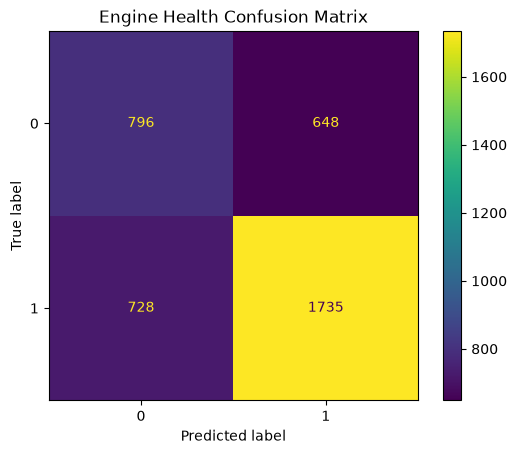

In [37]:
cm=confusion_matrix(y_test, y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Engine Health Confusion Matrix")
plt.show()

In [38]:
importance=pd.Series(
    model.feature_importances_,index=features
).sort_values(ascending=False)

print("Feature Importance:")
print(importance)

Feature Importance:
Engine rpm          0.227560
Fuel pressure       0.165918
lub oil temp        0.159436
Lub oil pressure    0.152527
Coolant temp        0.148344
Coolant pressure    0.146214
dtype: float64


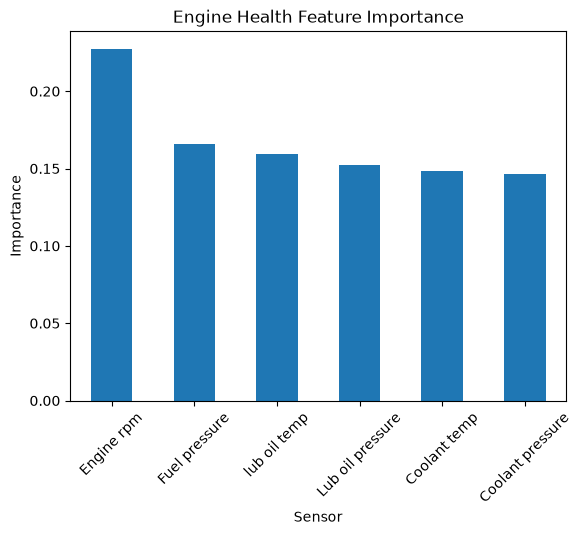

In [39]:
importance.plot(kind="bar")

plt.title("Engine Health Feature Importance")
plt.xlabel("Sensor")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

In [40]:
joblib.dump(
    model,"engine_health_model.pkl"
)
joblib.dump(scaler,"engine_health_scaler.pkl")

print("Model saved successfully")
print("scaler saved successfully")

Model saved successfully
scaler saved successfully


In [41]:
loaded_model=joblib.load("engine_health_model.pkl")
loaded_scaler=joblib.load("engine_health_scaler.pkl")

print("Model loaded:",loaded_model)
print("Scaler loaded:",loaded_scaler)

Model loaded: RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)
Scaler loaded: StandardScaler()


In [44]:
sample=x_test.iloc[[0]]

sample_scaled=loaded_scaler.transform(sample)

prediction=loaded_model.predict(sample_scaled)

print("Sensor values:")
print(sample)

print("\n Predicted Engine Condition:",prediction[0])
print("Actual Engine Condition:",y_test.iloc[0])

Sensor values:
      Engine rpm  Lub oil pressure  Fuel pressure  Coolant pressure  \
2830         634           2.61126      10.453517          2.771041   

      lub oil temp  Coolant temp  
2830      75.86364     79.245834  

 Predicted Engine Condition: 1
Actual Engine Condition: 1


In [45]:

# --------------------------------------------------
# Load trained model and scaler
# --------------------------------------------------

MODEL_PATH = "engine_health_model.pkl"
SCALER_PATH = "engine_health_scaler.pkl"


model = joblib.load(MODEL_PATH)
scaler = joblib.load(SCALER_PATH)


# --------------------------------------------------
# Vehicle Health Prediction Function
# --------------------------------------------------

def predict_vehicle_health(
    engine_rpm,
    oil_pressure,
    fuel_pressure,
    coolant_pressure,
    oil_temperature,
    coolant_temperature
):
    """
    Predict engine condition and generate
    vehicle health information.
    """

    # Arrange sensor values in the same order
    # used during model training.
    sensor_data = np.array([[
        engine_rpm,
        oil_pressure,
        fuel_pressure,
        coolant_pressure,
        oil_temperature,
        coolant_temperature
    ]])

    # Scale the sensor values
    sensor_data_scaled = scaler.transform(sensor_data)

    # Predict engine condition
    prediction = model.predict(sensor_data_scaled)[0]

    # Get prediction probability
    probabilities = model.predict_proba(sensor_data_scaled)[0]

    confidence = float(np.max(probabilities) * 100)


    # --------------------------------------------------
    # Convert model prediction into readable status
    # --------------------------------------------------

    if prediction == 1:

        condition = "Healthy"
        status = "Normal"

    else:

        condition = "Fault Detected"
        status = "Warning"


    # --------------------------------------------------
    # Calculate health score
    # --------------------------------------------------

    health_score = calculate_health_score(
        engine_rpm,
        oil_pressure,
        fuel_pressure,
        coolant_pressure,
        oil_temperature,
        coolant_temperature,
        prediction
    )


    # --------------------------------------------------
    # Generate recommendation
    # --------------------------------------------------

    recommendation = generate_recommendation(
        engine_rpm,
        oil_pressure,
        fuel_pressure,
        coolant_pressure,
        oil_temperature,
        coolant_temperature,
        prediction
    )


    return {
        "condition": condition,
        "status": status,
        "health_score": health_score,
        "confidence": round(confidence, 2),
        "recommendation": recommendation
    }


# --------------------------------------------------
# Health Score
# --------------------------------------------------

def calculate_health_score(
    rpm,
    oil_pressure,
    fuel_pressure,
    coolant_pressure,
    oil_temperature,
    coolant_temperature,
    prediction
):

    # Start with a base score
    score = 100


    # Engine RPM
    if rpm > 4000:
        score -= 10
    elif rpm > 3500:
        score -= 5


    # Oil pressure
    if oil_pressure < 2:
        score -= 20
    elif oil_pressure < 2.5:
        score -= 10


    # Coolant temperature
    if coolant_temperature > 105:
        score -= 20
    elif coolant_temperature > 100:
        score -= 10


    # Oil temperature
    if oil_temperature > 110:
        score -= 15
    elif oil_temperature > 100:
        score -= 8


    # Coolant pressure
    if coolant_pressure < 1.5:
        score -= 10


    # Vibration is not available in this dataset,
    # so we don't include it here.


    # If ML model detects a fault,
    # apply additional penalty.
    if prediction == 0:
        score -= 15


    # Keep score between 0 and 100
    score = max(0, min(100, score))

    return score


# --------------------------------------------------
# Maintenance Recommendation
# --------------------------------------------------

def generate_recommendation(
    rpm,
    oil_pressure,
    fuel_pressure,
    coolant_pressure,
    oil_temperature,
    coolant_temperature,
    prediction
):

    recommendations = []


    if oil_pressure < 2:
        recommendations.append(
            "Check engine lubrication and oil level."
        )

    if coolant_temperature > 105:
        recommendations.append(
            "Check coolant system and possible overheating."
        )

    if oil_temperature > 110:
        recommendations.append(
            "Check engine oil temperature."
        )

    if rpm > 4000:
        recommendations.append(
            "High engine RPM detected."
        )

    if coolant_pressure < 1.5:
        recommendations.append(
            "Inspect coolant pressure system."
        )

    if prediction == 0:
        recommendations.append(
            "Engine fault detected by AI model. "
            "Professional inspection is recommended."
        )


    if not recommendations:
        recommendations.append(
            "Engine parameters are within the expected range. "
            "Continue regular monitoring."
        )


    return recommendations